# Multi-Feature LSTMS:

So far we used a single feature to predict a 1d outcome, what if we use use more than one?

In this example, instead of using them individually, we will use them all in one model.

We will use Open, Close, High and Low, to predict the Close prices.

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense,LSTM,Dropout,Attention
import tensorflow as tf

SyntaxError: trailing comma not allowed without surrounding parentheses (880065032.py, line 6)

In [ ]:
# from keras.layers import Layer
# import keras.backend as K

# class AttentionLayer(Layer):
#     def _init_(self, **kwargs):
#         super(AttentionLayer, self)._init_(**kwargs)

#     def build(self, input_shape):
#         self.w = self.add_weight(name="att_weight", shape=(input_shape[-1],1),
#                                 initializer="zeros", trainable=True)
#         super(AttentionLayer, self).build(input_shape)

#     def call(self, x):
#         #Attention scores
#         e = tf.math.tanh(tf.tensordot(x, self.w, axes=1) + self.b)
#         a = tf.nn.softmax(e, axis=1)
#         #Apply attention to the input sequence
#         output = x*a
#         return tf.reduce_sum(output, axis=1)

#     def compute_output_shape(self, input_shape):
#         return (input_shape[0], input_shape[-1]) #Output shape is (batch_size, feature_dim) 

In [ ]:
data = pd.read_csv('stock_train_data.csv')
data["Close"]=pd.to_numeric(data.Close,errors='coerce')
data = data.dropna()

In [193]:
data["Close"]=pd.to_numeric(data.Close,errors='coerce')
data = data.dropna()

trainData = data.iloc[:,1:5].values
rows, columns = trainData.shape
scMulti = MinMaxScaler(feature_range=(0,1))

for i in range(columns):
    trainData[:,i:i+1] = scMulti.fit_transform(trainData[:,i:i+1])

In [194]:
X_train = []
y_train = []

for i in range (60,1149): #60 : timestep // 1149 : length of the data
    X_train.append(trainData[i-60:i]) 
    y_train.append(trainData[i,3:])

X_train,y_train = np.array(X_train),np.array(y_train)

print(X_train.shape)
print(y_train.shape)

(1089, 60, 4)
(1089, 1)


In [195]:
X_train = np.reshape(X_train,(X_train.shape[0],X_train.shape[1],4)) #adding the batch_size axis
X_train.shape

(1089, 60, 4)

Use the hyperparameters we found when tuning:

In [ ]:
def create_and_train_model(X_train, y_train, epochs=20, batch_size=32, inputs = 1, dropout = 0.4, units = 100):
    # Define the model architecture
    model = Sequential()
    model.add(LSTM(units=units, return_sequences=True, input_shape=(X_train.shape[1], inputs)))
    model.add(Dropout(dropout))
    model.add(Dense(units=1))
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train the model
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=2)

    return model, history

In [213]:
modelMulti, histMulti = create_and_train_model(X_train, y_train, inputs = 4, epochs=60, batch_size=128, units = 100, dropout = 0.4)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


ValueError: Only input tensors may be passed as positional arguments. The following argument value should be passed as a keyword argument: <LSTM name=lstm_16, built=True> (of type <class 'keras.src.layers.rnn.lstm.LSTM'>)

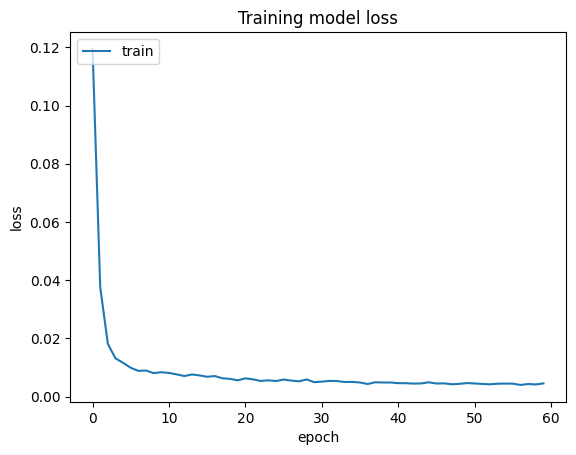

In [128]:
plt.plot(histMulti.history['loss'])
plt.title('Training model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train'], loc='upper left')
plt.show()

In [ ]:
# Load and preprocess the test data
testDataMulti = pd.read_csv('Google_test_data.csv')
testDataMulti["Close"] = pd.to_numeric(testDataMulti.Close, errors='coerce')
testDataMulti = testDataMulti.dropna()

# Extract the relevant columns (Open, High, Low, Close)
testDataMulti = testDataMulti.iloc[:, 1:5]  # Assuming these are the columns for Open, High, Low, Close

# Prepare the y_test array (actual values to compare predictions with)
y_test_multi = testDataMulti.iloc[60:, 3:].values  # Actual values from the 60th row onwards

# Input array for the model
inputMulti = testDataMulti.values  # Full dataset as NumPy array
for i in range(columns):
    inputMulti[:,i:i+1] = scMulti.transform(inputMulti[:,i:i+1])  # Scale the data
inputMulti.shape  # Shape: (length, 4)

# Prepare the X_test array
X_test = []
length = len(testDataMulti)
timestep = 60

for i in range(timestep, length):
    # Append the last 60 timesteps of all features for each row
    X_test.append(inputMulti[i-timestep:i, :])  # Shape: (60, 4)

# Convert to NumPy array and reshape
X_test = np.array(X_test)  # Convert to a NumPy array
print("X_test shape:", X_test.shape)  # Expected shape: (192, 60, 4)
print("y_test_multi shape:", y_test_multi.shape)  # Expected shape: (192, 4)

X_test shape: (192, 60, 4)
y_test_multi shape: (192, 1)
[[[1.73050859 1.7590332  1.72276079 1.72593747]
  [1.72635498 1.75113698 1.70296544 1.74238903]
  [1.71259516 1.72647111 1.66676724 1.67806758]
  ...
  [1.35650652 1.37547563 1.32555216 1.34304808]
  [1.35170313 1.37315523 1.30733707 1.31471607]
  [1.30824206 1.31629379 1.2299053  1.27364481]]

 [[1.72635498 1.75113698 1.70296544 1.74238903]
  [1.71259516 1.72647111 1.66676724 1.67806758]
  [1.70208367 1.70503063 1.65061734 1.65975958]
  ...
  [1.35170313 1.37315523 1.30733707 1.31471607]
  [1.30824206 1.31629379 1.2299053  1.27364481]
  [1.27222939 1.32992614 1.26895755 1.31012173]]

 [[1.71259516 1.72647111 1.66676724 1.67806758]
  [1.70208367 1.70503063 1.65061734 1.65975958]
  [1.64941069 1.66563027 1.61741227 1.6469277 ]
  ...
  [1.30824206 1.31629379 1.2299053  1.27364481]
  [1.27222939 1.32992614 1.26895755 1.31012173]
  [1.34072768 1.4021254  1.33353449 1.39732229]]

 ...

 [[1.45412566 1.57817421 1.45133195 1.56165296]
  

In [158]:
y_pred_multi = modelMulti.predict(X_test)
y_pred_multi.shape

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


(192, 1)

In [162]:
predicted_price_multi = scMulti.inverse_transform(y_pred_multi)
y_test_multi = scMulti.inverse_transform(y_test_multi)

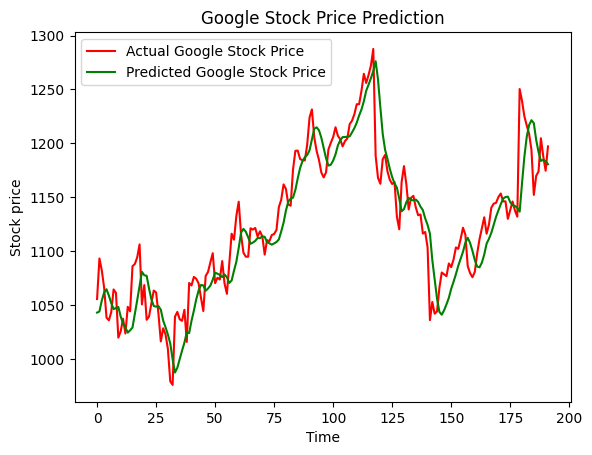

In [163]:
# # Define feature names for better labeling
# features = ['Open', 'High', 'Low', 'Close']

# # Create subplots (2 rows x 2 columns)
# fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# # Flatten axes array for easier indexing
# axs = axs.ravel()

# # Plot each feature
# for i, feature in enumerate(features):
#     axs[i].plot(y_test_multi[:, i], color='red', label=f'Actual {feature} Price')
#     axs[i].plot(predicted_price_multi[:, i], color='green', label=f'Predicted {feature} Price')
#     axs[i].set_title(f'{feature} Price Prediction')
#     axs[i].set_xlabel('Time')
#     axs[i].set_ylabel('Price')
#     axs[i].legend()

# # Adjust layout to prevent overlap
# plt.tight_layout()
# plt.show()

plt.plot(y_test_multi, color='red', label='Actual Google Stock Price')
plt.plot(predicted_price_multi, color='green', label='Predicted Google Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock price')
plt.legend()

In [168]:
def calculate_accuracy(real, predict):
    real = np.array(real) + 1
    predict = np.array(predict) + 1
    percentage = 1 - np.sqrt(np.mean(np.square((real - predict) / real)))
    return percentage * 100

In [170]:
# Over vs under predict

In [ ]:
from sklearn.metrics import mean_squared_error

print(calculate_accuracy(y_test_multi, predicted_price_multi))


740.2025001175201
97.58950123309953


Using a new data set:

In [53]:
data = pd.read_csv('tesla.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2193 entries, 0 to 2192
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2193 non-null   object 
 1   Open       2193 non-null   float64
 2   High       2193 non-null   float64
 3   Low        2193 non-null   float64
 4   Close      2193 non-null   float64
 5   Adj Close  2193 non-null   float64
 6   Volume     2193 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 120.1+ KB


In [54]:
data.shape

(2193, 7)

In [55]:
data = data.iloc[:,1:6].values #to numpyarray

We have to make the split ourselves now for training vs testing. The standard is 80/20, so I will do that.

In [57]:
splitValue = int(len(data) * 0.8)
trainingData, testingData = data[:splitValue], data[splitValue:]

In [58]:
scMulti = MinMaxScaler(feature_range=(0,1))
trainingData = scMulti.fit_transform(trainingData)

In [59]:
X_train = []
y_train = []

for i in range (60,1149): #60 : timestep // 1149 : length of the data #we can adjsut the timestep??
    X_train.append(trainingData[i-60:i]) 
    y_train.append(trainingData[i])

X_train,y_train = np.array(X_train),np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(1089, 60, 5)
(1089, 5)


In [61]:
X_train = np.reshape(X_train,(X_train.shape[0],X_train.shape[1],5)) #adding the batch_size axis
X_train.shape

(1089, 60, 5)

In [62]:
modelMulti, histMulti = create_and_train_model(X_train, y_train, features = 5, epochs=60, batch_size=64, units = 50, dropout = 0.2)

Epoch 1/60


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 - 1s - 69ms/step - loss: 0.0617
Epoch 2/60
18/18 - 0s - 20ms/step - loss: 0.0097
Epoch 3/60
18/18 - 0s - 19ms/step - loss: 0.0053
Epoch 4/60
18/18 - 0s - 17ms/step - loss: 0.0044
Epoch 5/60
18/18 - 0s - 21ms/step - loss: 0.0045
Epoch 6/60
18/18 - 0s - 20ms/step - loss: 0.0036
Epoch 7/60
18/18 - 0s - 20ms/step - loss: 0.0035
Epoch 8/60
18/18 - 0s - 18ms/step - loss: 0.0032
Epoch 9/60
18/18 - 0s - 19ms/step - loss: 0.0027
Epoch 10/60
18/18 - 0s - 19ms/step - loss: 0.0030
Epoch 11/60
18/18 - 0s - 19ms/step - loss: 0.0032
Epoch 12/60
18/18 - 0s - 19ms/step - loss: 0.0027
Epoch 13/60
18/18 - 0s - 19ms/step - loss: 0.0025
Epoch 14/60
18/18 - 0s - 20ms/step - loss: 0.0026
Epoch 15/60
18/18 - 0s - 19ms/step - loss: 0.0025
Epoch 16/60
18/18 - 0s - 19ms/step - loss: 0.0021
Epoch 17/60
18/18 - 0s - 19ms/step - loss: 0.0020
Epoch 18/60
18/18 - 0s - 19ms/step - loss: 0.0021
Epoch 19/60
18/18 - 0s - 18ms/step - loss: 0.0021
Epoch 20/60
18/18 - 0s - 18ms/step - loss: 0.0020
Epoch 21/60
18/18 - 

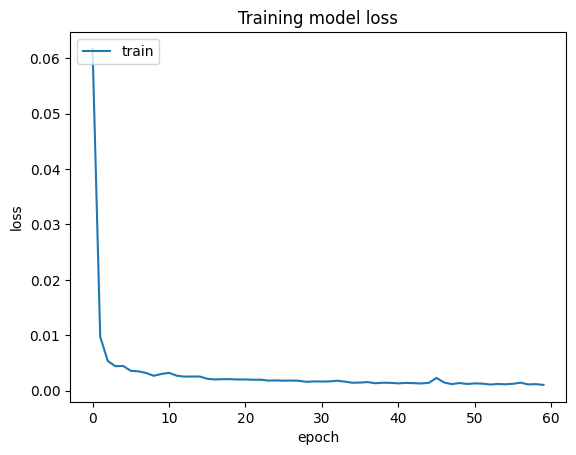

In [63]:
plt.plot(histMulti.history['loss'])
plt.title('Training model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train'], loc='upper left')
plt.show()

In [69]:
# Prepare the y_test array (actual values to compare predictions with)
y_test_multi = testingData[60:, :]  # Actual values from the 60th row onwards

# Input array for the model
inputMulti = testingData  # Full dataset as NumPy array
inputMulti_scaled = scMulti.transform(inputMulti)  # Scale the data
inputMulti_scaled.shape  # Shape: (length, 4)

# Prepare the X_test array
X_test = []
length = len(testingData)
timestep = 60

for i in range(timestep, length):
    # Append the last 60 timesteps of all features for each row
    X_test.append(inputMulti_scaled[i-timestep:i, :])  # Shape: (60, 4)

# Convert to NumPy array and reshape
X_test = np.array(X_test)  # Convert to a NumPy array
print("X_test shape:", X_test.shape)  # Expected shape: (192, 60, 4)
print("y_test_multi shape:", y_test_multi.shape)  # Expected shape: (192, 4)

X_test shape: (379, 60, 5)
y_test_multi shape: (379, 5)


In [70]:
y_pred_multi = modelMulti.predict(X_test)
y_pred_multi.shape

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


(379, 5)

In [71]:
predicted_price_multi = scMulti.inverse_transform(y_pred_multi)

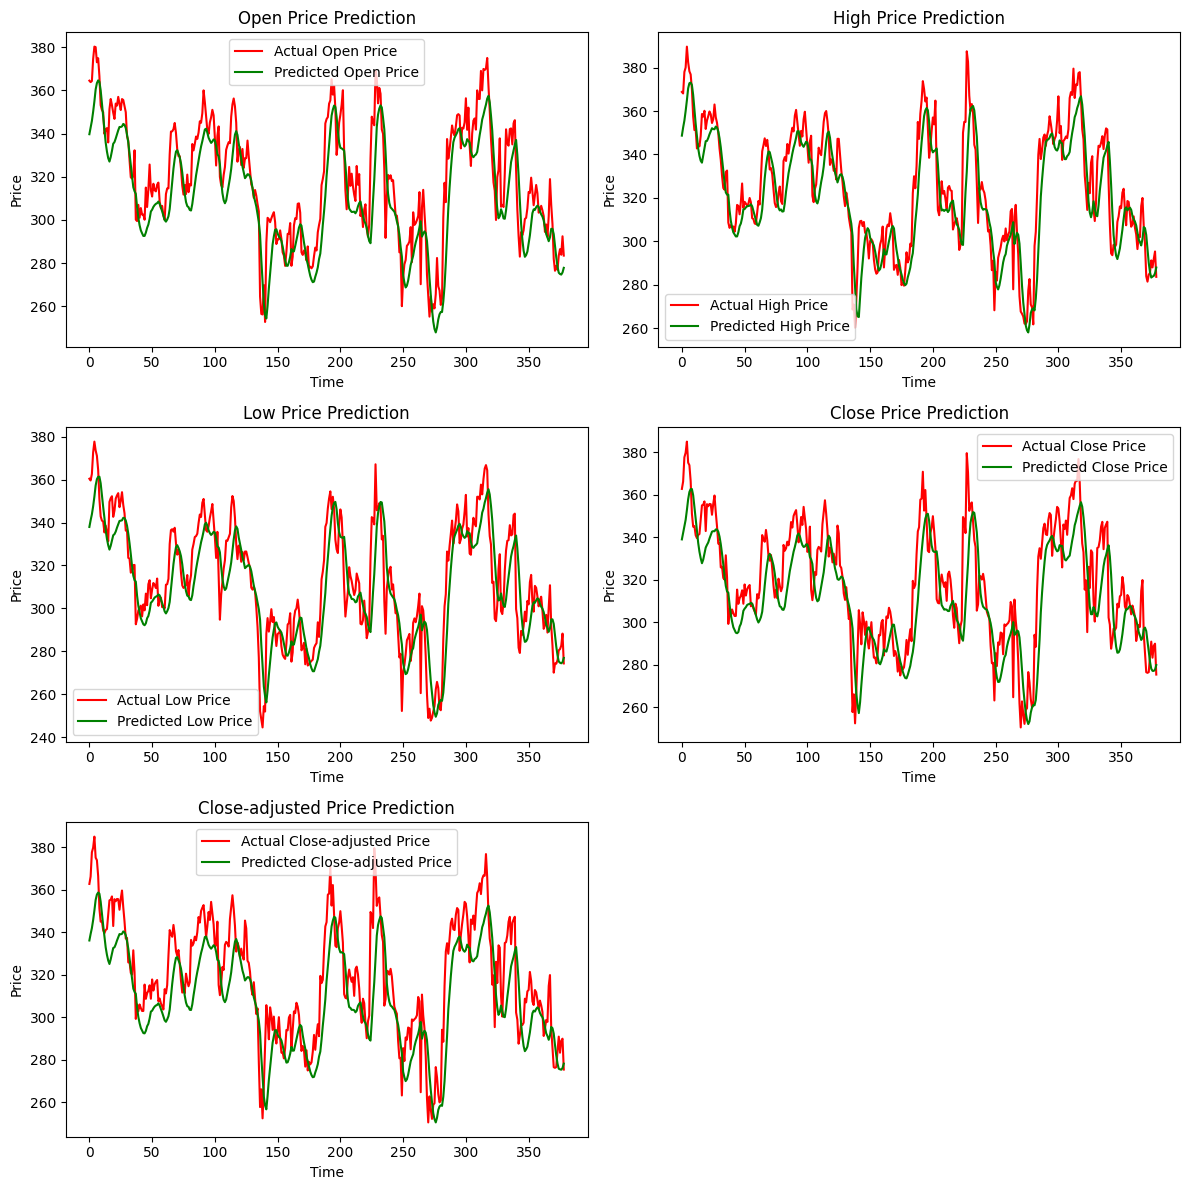

In [73]:
# Define feature names for better labeling
features = ['Open', 'High', 'Low', 'Close', 'Close-adjusted']

# Create subplots (3 rows x 2 columns)
fig, axs = plt.subplots(3, 2, figsize=(12, 12))

# Flatten axes array for easier indexing
axs = axs.ravel()

# Plot each feature
for i, feature in enumerate(features):
    axs[i].plot(y_test_multi[:, i], color='red', label=f'Actual {feature} Price')
    axs[i].plot(predicted_price_multi[:, i], color='green', label=f'Predicted {feature} Price')
    axs[i].set_title(f'{feature} Price Prediction')
    axs[i].set_xlabel('Time')
    axs[i].set_ylabel('Price')
    axs[i].legend()

# Turn off the last subplot (unused)
axs[-1].axis('off')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In [216]:
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier
import keras_tuner

In [ ]:
#Stock prices in seperate folder

#Function 1: reads data, splits into training and testing if necessary

#Function 2: Hyperparameter tune

#Function 3: Run model, with hyperpamaters tuned

#Function 4: Predict and compare to test data

# Put all of this in a class?? 
class StockPredictor():
    def __init__(self, StockName):
        self.StockName = StockName
        self.TrainPercent = 0.8
        self.ValidationPercent = 0.2
        self.TrainData = None
        self.TestData = None
        self.X_train = None
        self.y_train = None
        self.TimeStep = 60
        self.BatchSize = None
        self.Dropout = None
        self.Units = None
        self.history = None
        self.Model = None
        self.Trainscaler = None
        self.X_test = None
        self.y_test = None
        self.accuracy = None
        self.predicted_price = None
        self.Retune = False

    def preprocess_google(self):
        self.TrainData["Close"]=pd.to_numeric(self.TrainData.Close,errors='coerce')
        self.TrainData = self.TrainData.dropna()

    functions = {
        'Google': preprocess_google,
    }
    
    def readData(self, FileNameTrain, FileNameTest):
        #check if FileNames exist

        #if second one is None, we know we split from train

        # # if that is the case, train = 80%, test = 20%

        #return training set, testing set, and scaler 

        try:
            trainingData = pd.read_csv(FileNameTrain)    
        except:
            print("File not found or not csv file")
        
        if FileNameTest is None:
            splitValue = int(len(trainingData) * self.TrainPercent)
            trainingData, testingData = trainingData.iloc[:splitValue], trainingData.iloc[splitValue:]
            # print("Training Data")
            # print(trainingData)
            # print("Testing Data")
            # print(testingData)
        else:
            try:
                testingData = pd.read_csv(FileNameTest)    
            except:
                print("File not found or not csv file")
        self.TrainData = trainingData
        self.TestData = testingData
        try: 
            preprocess_function = self.functions[self.StockName]
        except:
            print("no preprocessor ")
        else:
            preprocess_function(self)

        #setting timestep:

        if (len(self.TestData) < 2 * self.TimeStep):
            print("WARNING: test data does not contain enough instances to generate accurate results")
            self.TimeStep = int(len(self.TestData) * 1/3) #arbitrary value for now
    
    def dataPreprocess():
        pass
        
    def processTrain(self, trainData, numCol = 4, predictionCol = 3):
        rows, columns = trainData.shape
        scaler = MinMaxScaler(feature_range=(0,1))

        self.Trainscaler = scaler
        
        for i in range(columns):
            trainData[:,i:i+1] = scaler.fit_transform(trainData[:,i:i+1])

        X_train = []
        y_train = []
        
        for i in range (self.TimeStep, len(trainData)): #
            X_train.append(trainData[i-self.TimeStep:i]) 
            y_train.append(trainData[i,predictionCol:]) #close happens to be the 4th column in that specific

        X_train,y_train = np.array(X_train),np.array(y_train)

        # print(X_train.shape)
        # print(y_train.shape)

        X_train = np.reshape(X_train,(X_train.shape[0],X_train.shape[1],numCol))
        
        # self.X_train = X_train
        # self.Y_train = y_train
        return X_train, y_train
        
    
    def build_model(self, hp):
        model = Sequential()
        # Tune the number of LSTM units
        units = hp.Int('units', min_value=50, max_value=300, step=50)
        model.add(LSTM(units, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
        batch_sizes = hp.Choice('batch_size', [16, 32, 64, 128, 264])
        # Tune the dropout rate
        dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.6, step=0.1)
        model.add(Dropout(dropout_rate))
        model.add(Dense(X_train.shape[2]))
        model.compile(
            optimizer='adam', #should we tune this as well?
            loss='mean_squared_error', #how do we decide between them?
            metrics=['accuracy']
        )
        return model

    def hyperParameterTuning(self, X_train, y_train, features, numTrials = 20, executionPerTrial = 1, trainEpochs = 10):
        #use train set to tune hyperparameters

        #split some of train set as validation set

        #return the hyperparameters
        split_ratio = 1 - self.ValidationPercent

        train_size = int(len(X_train) * split_ratio)

        X_train, X_val = X_train[:train_size], X_train[train_size:]
        y_train, y_val = y_train[:train_size], y_train[train_size:]

        print(X_val.shape)
        print(y_val.shape)

        X_train = np.reshape(X_train,(X_train.shape[0],X_train.shape[1], features)) #edit later probably


        tuner = keras_tuner.RandomSearch(
            self.build_model,
            objective='val_accuracy',
            max_trials=numTrials,  # Number of different hyperparameter combinations to try
            executions_per_trial=executionPerTrial,  # Number of models to train per combination
            #directory='my_dir', #Where it saves all the trials
            #project_name='lstm_tuning'
        )

        # Perform the search
        tuner.search(
            X_train,
            y_train,
            epochs=trainEpochs, #use less epochs for training to make it faster
            validation_data=(X_val, y_val))

        # Retrieve the best hyperparameters
        best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
        print(f"Best number of units: {best_hps.get('units')}")
        print(f"Best dropout rate: {best_hps.get('dropout_rate')}")
        print(f"Best batch size: {best_hps.get('batch_size')}")

        self.BatchSize = best_hps.get('batch_size')
        self.Units = best_hps.get('units')
        self.Dropout = best_hps.get('dropout_rate')


    def defineAndTrainModel(self, X_train, y_train, epochs = 60, inputs = 1): #hyperparameters as inputs
        #define our model with the hyperparameters

        #train it

        #return model and history (also output it here?)
        model = Sequential()
        model.add(LSTM(units=self.Units, return_sequences=False, input_shape=(X_train.shape[1], inputs)))
        model.add(Dropout(self.Dropout))
        model.add(Dense(units=1))
        model.compile(optimizer='adam', loss='mean_squared_error')

        # Train the model
        history = model.fit(X_train, y_train, epochs=epochs, batch_size=self.BatchSize, verbose=2)

        self.history = history
        self.Model = model

    def processTest(self, testData, predictionCol = 3, UseNewScaler = False): #assuming preprocesed testSet
        #predict using our training set

        #output prediction with accuracy 

        y_test = testData.iloc[self.TimeStep:, predictionCol:].values  # assuming close is the 

        # Input array for the model
        inputMulti = testData.values  # Full dataset as NumPy array

        if (UseNewScaler):
            self.Testscaler = MinMaxScaler(feature_range=(0,1))
        else:
            self.Testscaler = self.Trainscaler
        for i in range(testData.shape[1]):
            print(inputMulti[:,i:i+1])
            inputMulti[:,i:i+1] = self.Testscaler.fit_transform(inputMulti[:,i:i+1])  # Scale the data
        inputMulti.shape  # Shape: (length, 4)

        # Prepare the X_test array
        X_test = []
        print("Len of testData: ", len(testData))
        print("Len of inputmult: ", len(testData))
        length = len(testData)

        for i in range(self.TimeStep, length):
            # Append the last 60 timesteps of all features for each row
            X_test.append(inputMulti[i-self.TimeStep:i, :])  # Shape: (60, 4)

        # Convert to NumPy array and reshape
        X_test = np.array(X_test)  # Convert to a NumPy array
        print("X_test shape:", X_test.shape)  # Expected shape: (192, 60, 4)
        print("y_test_multi shape:", y_test.shape)  # Expected shape: (192, 4)

        # self.X_test = X_test
        # self.y_test = y_test
        return X_test, y_test

    def calculate_accuracy(real, predict):
        real = np.array(real) + 1
        predict = np.array(predict) + 1
        percentage = 1 - np.sqrt(np.mean(np.square((real - predict) / real)))
        return percentage * 100

    def predict(self, X_test, y_test):
        y_pred = self.Model.predict(X_test)
        predicted_price = self.Trainscaler.inverse_transform(y_pred)
        y_test = self.Testscaler.inverse_transform(y_test)

        self.y_test = y_test
        self.predicted_price = predicted_price

        plt.plot(y_test, color='red', label=f'Actual {self.StockName} Stock Price')
        plt.plot(predicted_price, color='green', label=f'Predicted {self.StockName} Stock Price')
        plt.title(f'{self.StockName} Stock Price Prediction')
        plt.xlabel('Time')
        plt.ylabel('Stock price')
        plt.legend()

        for i in range(len(y_test)):
            print(f"Y Test: {y_test[i]}, predicted: {predicted_price[i]}")

        self.accuracy = calculate_accuracy(y_test, predicted_price)

[[[0.08581368 0.09640129 0.09044931 0.40001392]
  [0.09701243 0.09834351 0.09823458 0.40665027]
  [0.09433366 0.09251685 0.09408623 0.38520976]
  ...
  [0.07846566 0.07903337 0.0783452  0.36279469]
  [0.08034452 0.08276841 0.08330808 0.35745777]
  [0.08497656 0.08751191 0.08921806 0.37766846]]

 [[0.09701243 0.09834351 0.09823458 0.40665027]
  [0.09433366 0.09251685 0.09408623 0.38520976]
  [0.09156187 0.08881917 0.08800576 0.36439577]
  ...
  [0.08034452 0.08276841 0.08330808 0.35745777]
  [0.08497656 0.08751191 0.08921806 0.37766846]
  [0.08627874 0.08564439 0.08283452 0.36065992]]

 [[0.09433366 0.09251685 0.09408623 0.38520976]
  [0.09156187 0.08881917 0.08800576 0.36439577]
  [0.07984225 0.07671765 0.06106986 0.30063115]
  ...
  [0.08497656 0.08751191 0.08921806 0.37766846]
  [0.08627874 0.08564439 0.08283452 0.36065992]
  [0.08471612 0.08274973 0.07970905 0.34406906]]

 ...

 [[0.92106928 0.92416008 0.93248977 0.65286802]
  [0.92438053 0.92909033 0.9389112  0.66184797]
  [0.93048

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


69/69 - 2s - 28ms/step - loss: 0.0298
Epoch 2/15
69/69 - 1s - 11ms/step - loss: 0.0093
Epoch 3/15
69/69 - 1s - 11ms/step - loss: 0.0077
Epoch 4/15
69/69 - 1s - 11ms/step - loss: 0.0077
Epoch 5/15
69/69 - 1s - 11ms/step - loss: 0.0059
Epoch 6/15
69/69 - 1s - 11ms/step - loss: 0.0062
Epoch 7/15
69/69 - 1s - 11ms/step - loss: 0.0064
Epoch 8/15
69/69 - 1s - 11ms/step - loss: 0.0045
Epoch 9/15
69/69 - 1s - 12ms/step - loss: 0.0051
Epoch 10/15
69/69 - 1s - 11ms/step - loss: 0.0056
Epoch 11/15
69/69 - 1s - 11ms/step - loss: 0.0050
Epoch 12/15
69/69 - 1s - 11ms/step - loss: 0.0045
Epoch 13/15
69/69 - 1s - 11ms/step - loss: 0.0044
Epoch 14/15
69/69 - 1s - 11ms/step - loss: 0.0041
Epoch 15/15
69/69 - 1s - 14ms/step - loss: 0.0040
            Open         High          Low        Close
0    1236.979980  1249.272949  1233.640991  1235.010010
1    1235.189941  1245.869995  1225.109985  1242.099976
2    1229.260010  1235.239990  1209.510010  1214.380005
3    1224.729980  1226.000000  1202.550049  12

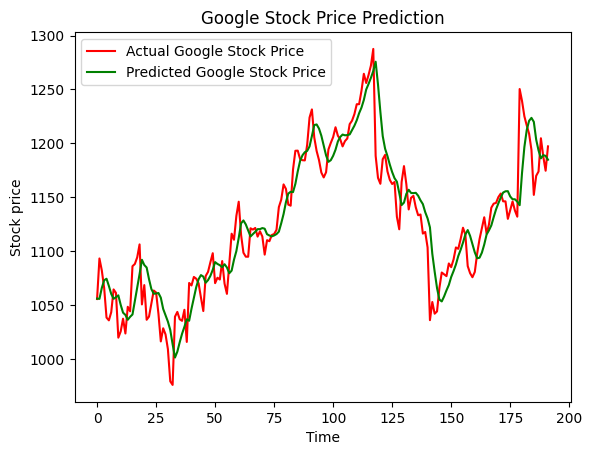

In [360]:
def main():
    stock = StockPredictor("Google")
    stock.readData("Google_train_data.csv", "Google_test_data.csv")
    
    X_train, y_train = stock.processTrain(stock.TrainData.iloc[:,1:5].values)
    print(X_train)
    if (stock.Retune):
        stock.hyperParameterTuning(X_train, y_train, 4)
    print(stock.BatchSize, stock.Dropout, stock.Units)
    stock.BatchSize = 16
    stock.Dropout = 0.3
    stock.Units = 50
    stock.defineAndTrainModel(X_train, y_train, inputs=4, epochs=15)
    print(stock.TestData.iloc[:,1:5])
    X_test, y_test = stock.processTest(stock.TestData.iloc[:,1:5])
    print(X_test)
    print(y_test)
    stock.predict(X_test, y_test)
    print(stock.accuracy)

main()

no preprocessor 
           Date        Open        High         Low       Close   Adj Close  \
201  2019-03-13  172.320007  174.029999  172.119995  173.369995  173.369995   
202  2019-03-14  169.759995  171.149994  168.160004  170.169998  170.169998   
203  2019-03-15  167.160004  167.580002  162.509995  165.979996  165.979996   
204  2019-03-18  163.570007  163.899994  159.279999  160.470001  160.470001   
205  2019-03-19  161.479996  163.820007  160.820007  161.570007  161.570007   
206  2019-03-20  161.500000  166.119995  161.240005  165.440002  165.440002   
207  2019-03-21  164.889999  166.389999  163.750000  166.080002  166.080002   
208  2019-03-22  165.649994  167.419998  164.089996  164.339996  164.339996   
209  2019-03-25  163.000000  166.539993  162.000000  166.289993  166.289993   
210  2019-03-26  167.350006  169.449997  166.350006  167.679993  167.679993   
211  2019-03-27  167.850006  168.940002  164.789993  165.869995  165.869995   
212  2019-03-28  164.570007  166.72

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 - 1s - 113ms/step - loss: 0.0252
Epoch 2/15
12/12 - 0s - 5ms/step - loss: 0.0184
Epoch 3/15
12/12 - 0s - 5ms/step - loss: 0.0111
Epoch 4/15
12/12 - 0s - 5ms/step - loss: 0.0107
Epoch 5/15
12/12 - 0s - 5ms/step - loss: 0.0096
Epoch 6/15
12/12 - 0s - 5ms/step - loss: 0.0091
Epoch 7/15
12/12 - 0s - 6ms/step - loss: 0.0109
Epoch 8/15
12/12 - 0s - 6ms/step - loss: 0.0097
Epoch 9/15
12/12 - 0s - 8ms/step - loss: 0.0098
Epoch 10/15
12/12 - 0s - 10ms/step - loss: 0.0085
Epoch 11/15
12/12 - 0s - 9ms/step - loss: 0.0079
Epoch 12/15
12/12 - 0s - 7ms/step - loss: 0.0098
Epoch 13/15
12/12 - 0s - 6ms/step - loss: 0.0080
Epoch 14/15
12/12 - 0s - 13ms/step - loss: 0.0067
Epoch 15/15
12/12 - 0s - 7ms/step - loss: 0.0069
           Open        High         Low       Close
201  172.320007  174.029999  172.119995  173.369995
202  169.759995  171.149994  168.160004  170.169998
203  167.160004  167.580002  162.509995  165.979996
204  163.570007  163.899994  159.279999  160.470001
205  161.479996  163.

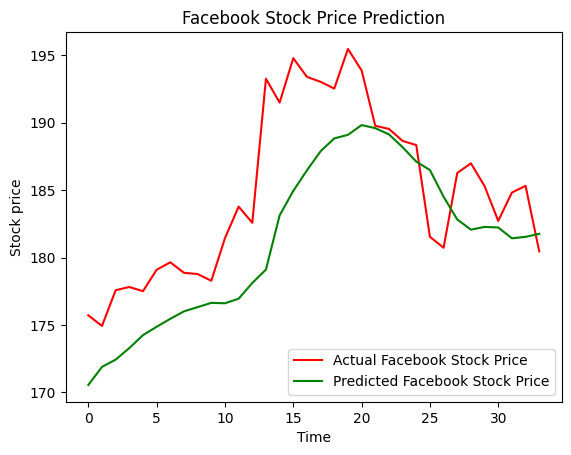

In [359]:
def main():
    stock = StockPredictor("Facebook")
    stock.readData("FB.csv", None)
    
    X_train, y_train = stock.processTrain(stock.TrainData.iloc[:,1:5].values)
    print(stock.TestData)
    if (stock.Retune):
        stock.hyperParameterTuning(X_train, y_train, 4)
    print(stock.BatchSize, stock.Dropout, stock.Units)
    stock.BatchSize = 16
    stock.Dropout = 0.3
    stock.Units = 50
    stock.defineAndTrainModel(X_train, y_train, inputs=4, epochs=15)
    print(stock.TestData.iloc[:,1:5])
    X_test, y_test = stock.processTest(stock.TestData.iloc[:,1:5])
    print(X_test)
    print(y_test)
    stock.predict(X_test, y_test)
    print(stock.accuracy)

main()

In [ ]:
import streamlit as st

class StockPredictor:
    def __init__(self, StockName):
        self.StockName = StockName
        self.TrainPercent = 0.8
        self.ValidationPercent = 0.2
        self.TrainData = None
        self.TestData = None
        self.X_train = None
        self.y_train = None
        self.TimeStep = 60
        self.BatchSize = None
        self.Dropout = None
        self.Units = None
        self.history = None
        self.Model = None
        self.Trainscaler = None
        self.X_test = None
        self.y_test = None
        self.accuracy = None
        self.predicted_price = None
        self.Retune = False

    def main(self):
        # Example placeholder for the main logic
        st.write(f"Running model for stock: {self.StockName}")
        st.write(f"Training Percentage: {self.TrainPercent * 100}%")
        st.write(f"Validation Percentage: {self.ValidationPercent * 100}%")
        st.write("Model setup complete. Add your logic to train and evaluate the model.")

# Streamlit App
def app():
    st.title("Stock Predictor")

    # Input: Stock Name
    stock_name = st.text_input("Enter the Stock Name:", value="AAPL")

    # Optional parameters
    train_percent = st.slider("Training Data Percentage:", min_value=0.5, max_value=0.9, value=0.8, step=0.05)
    time_step = st.number_input("Time Step (lookback window):", min_value=10, max_value=120, value=60, step=5)
    batch_size = st.selectbox("Batch Size:", options=[16, 32, 64, 128], index=1)
    dropout = st.slider("Dropout Rate:", min_value=0.0, max_value=0.5, value=0.2, step=0.05)
    units = st.slider("LSTM Units:", min_value=50, max_value=300, value=100, step=50)
    retune = st.checkbox("Enable Retuning")

    # Submit Button
    if st.button("Run Model"):
        # Initialize StockPredictor
        predictor = StockPredictor(stock_name)
        predictor.TrainPercent = train_percent
        predictor.ValidationPercent = 1 - train_percent
        predictor.TimeStep = time_step
        predictor.BatchSize = batch_size
        predictor.Dropout = dropout
        predictor.Units = units
        predictor.Retune = retune

        # Run main function
        predictor.main()

# Run the app
if __name__ == "__main__":
    app()


2024-12-23 17:02:50.169 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-12-23 17:02:50.173 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-12-23 17:02:50.175 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-12-23 17:02:50.177 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-12-23 17:02:50.182 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-12-23 17:02:50.184 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-12-23 17:02:50.186 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-12-23 17:02:50.187 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar